## <center>CITS5508 Lab sheet 6</center>

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

## Concrete Slump Test

In [10]:
df = pd.read_csv('slump_test.data', index_col=0)

df.drop(columns=['SLUMP(cm)', 'FLOW(cm)'], inplace=True)
df.rename(columns={'Compressive Strength (28-day)(Mpa)': 'Compressive Strength'}, inplace=True)

In [11]:
df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,Compressive Strength
No,,,,,,,,
1,273.0,82.0,105.0,210.0,9.0,904.0,680.0,34.99
2,163.0,149.0,191.0,180.0,12.0,843.0,746.0,41.14
3,162.0,148.0,191.0,179.0,16.0,840.0,743.0,41.81
4,162.0,148.0,190.0,179.0,19.0,838.0,741.0,42.08
5,154.0,112.0,144.0,220.0,10.0,923.0,658.0,26.82


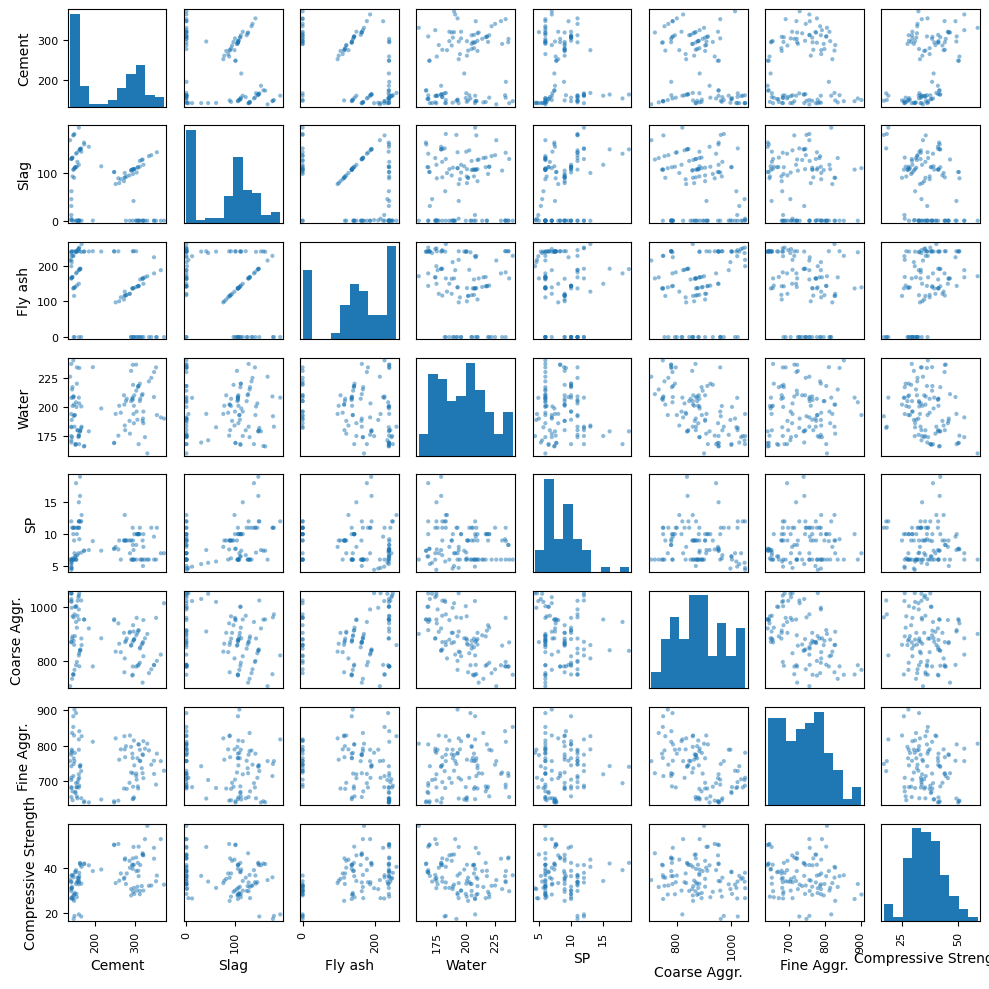

In [12]:
from pandas.plotting import scatter_matrix

scatter_matrix(df, figsize=(10, 10))

plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Compressive Strength')
y = df['Compressive Strength']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
)

In [ ]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

svm_reg = LinearSVR(random_state=42)
lin_reg = LinearRegression()
ridge_reg = SGDRegressor(penalty='l2', random_state=42)

voting_reg = VotingRegressor(
    estimators=[
        ('svm', svm_reg),
        ('lin', lin_reg),
        ('sgd', ridge_reg),
    ],
)

models = [
    (reg.__class__.__name__, make_pipeline(StandardScaler(), reg).fit(X_train, y_train)) for reg in [svm_reg, lin_reg, ridge_reg, voting_reg]
]

In [ ]:
def performance_tbl(models):
    r2s = []

    for name, reg in models:
        r2s.append({
            'model': name,
            'train': reg.score(X_train, y_train),
            'test': reg.score(X_test, y_test)
        })

    return pd.DataFrame(r2s).set_index('model')

performance_tbl(models)

,train,test
model,,
LinearSVR,0.840445,0.880884
LinearRegression,0.891069,0.915434
SGDRegressor,0.890703,0.916179
VotingRegressor,0.885357,0.921096


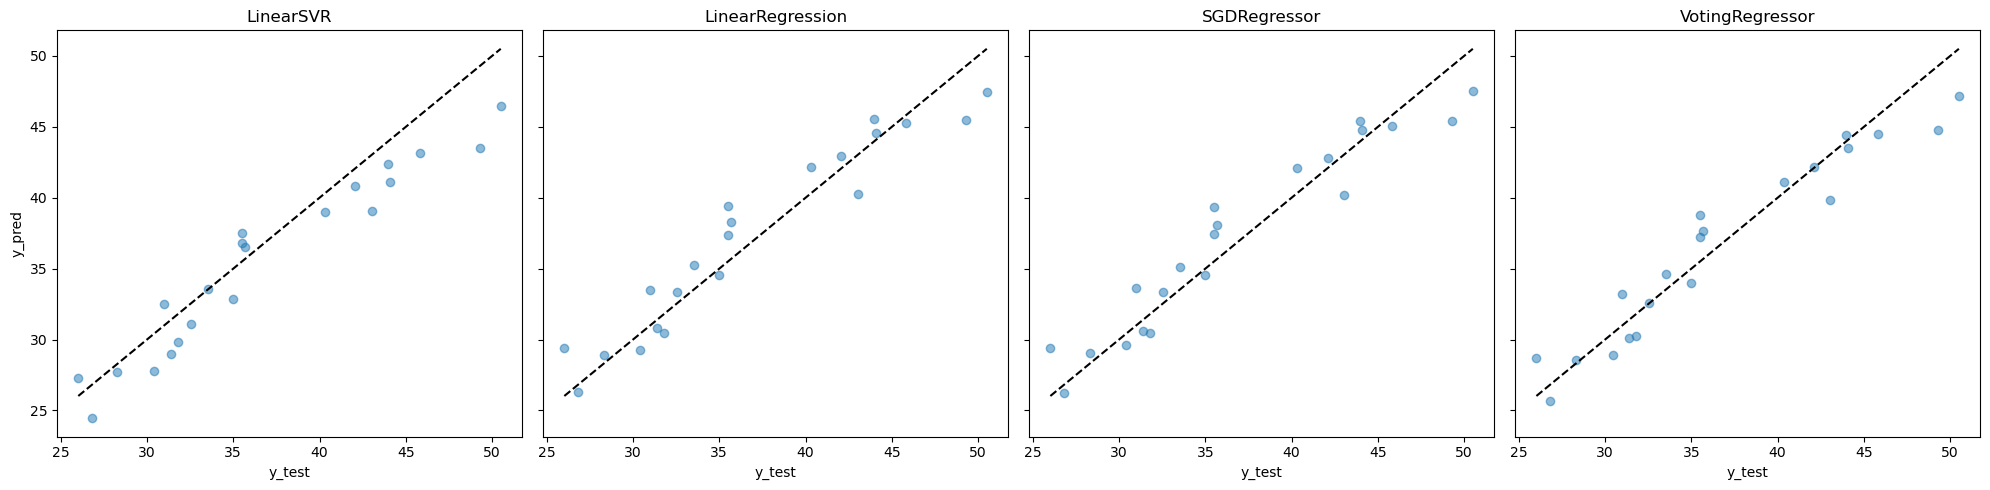

In [ ]:
def plot_reg(models):
    fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

    for i, (name, reg) in enumerate(models):
        y_pred = reg.predict(X_test)
        axs[i].scatter(y_test, y_pred, alpha=0.5)
        axs[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
        axs[i].set_title(name)
        axs[i].set_xlabel('y_test')

    axs[0].set_ylabel('y_pred')

    return fig, axs

fig, axs = plot_reg(models)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_svm_reg = GridSearchCV(
    LinearSVR(random_state=42, max_iter=10000),
    param_grid = {
        'C': [0.01, 0.1, 1.0, 10.0],
        'epsilon': [0.0, 0.1, 0.2],
        'loss': ['epsilon_insensitive', 'squared_epsilon_insensitive'],
    },
    cv=3,
    scoring='r2',
)

grid_lin_reg = LinearRegression()

grid_ridge_reg = GridSearchCV(
    SGDRegressor(penalty='l2', random_state=42, max_iter=1000),
    param_grid={
        'alpha': [1e-4, 1e-3],
        'learning_rate': ['constant', 'optimal'],
    },
    cv=3,
    scoring='r2',
)

grid_voting_reg = VotingRegressor(
    estimators=[
        ('svm', grid_svm_reg),
        ('lin', grid_lin_reg),
        ('sgd', grid_ridge_reg),
    ],
)

grid_models = [
    (reg.__class__.__name__, make_pipeline(StandardScaler(), reg).fit(X_train, y_train))
    for reg in [grid_svm_reg, grid_lin_reg, grid_ridge_reg, grid_voting_reg]
]

In [ ]:
performance_tbl(grid_models)

,train,test
model,,
GridSearchCV,0.891052,0.915905
LinearRegression,0.891069,0.915434
GridSearchCV,0.890551,0.915676
VotingRegressor,0.891001,0.915846


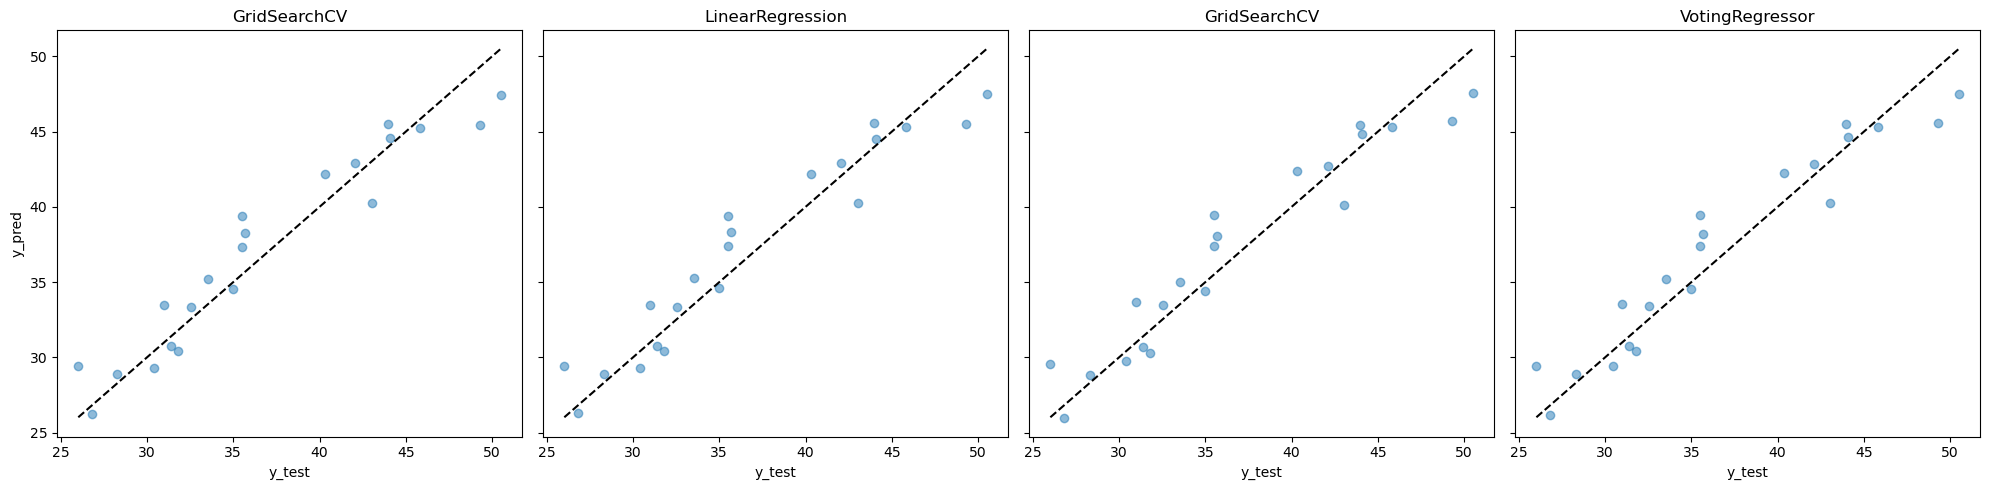

In [ ]:
fig, axs = plot_reg(grid_models)
plt.tight_layout()
plt.show()

## Abalone dataset

In [ ]:
df = pd.read_csv(
    'abalone.data', 
    header=None, 
    names=[
        'sex', 
        'length', 
        'diameter', 
        'height', 
        'whole_weight', 
        'shucked_weight', 
        'viscera_weight', 
        'shell_weight', 
        'rings'
    ]
)

df['sex'] = pd.factorize(df['sex'])[0]

In [ ]:
df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
X = df.drop(columns=['rings'])
y = df['rings']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

regr = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
).fit(X_train, y_train)

# optimal hyperparameters from previous lab
regr_opt = RandomForestRegressor(
    max_depth=9, 
    max_leaf_nodes=30, 
    min_samples_split=100, 
    n_estimators=100, 
    random_state=42
).fit(X_train, y_train)

In [ ]:
from sklearn.metrics import r2_score

def abalone_performance_tbl(models):
    r2s = []

    for name, reg in models:
        r2s.append({
            'model': name,
            'train': r2_score(y_train, reg.predict(X_train).round()),
            'test': r2_score(y_test, reg.predict(X_test).round())
        })

    return pd.DataFrame(r2s).set_index('model')

abalone_performance_tbl([
    ('Default params', regr),
    ('Optimal params', regr_opt),
])

,train,test
model,,
Default params,0.92991,0.560171
Optimal params,0.59145,0.556831


In [ ]:
mask = regr_opt.feature_importances_ >= 0.05
X_train_reduced = X_train.loc[:, mask]
X_test_reduced = X_test.loc[:, mask]

In [ ]:
print(f'total retained feature importance: {regr_opt.feature_importances_[mask].sum():.3f}')
print(f'removed features: {X.columns[~mask].tolist()}')

total retained feature importance: 0.898
removed features: ['sex', 'length', 'diameter', 'height', 'whole_weight', 'viscera_weight']


In [ ]:
regr_reduced = RandomForestRegressor(
    n_estimators=100, 
    random_state=42
).fit(X_train_reduced, y_train)

regr_opt_reduced = RandomForestRegressor(
    max_depth=9, 
    max_leaf_nodes=30, 
    min_samples_split=100, 
    n_estimators=100, 
    random_state=42
).fit(X_train_reduced, y_train)

In [ ]:
models = [
    ('Default reduced', regr_reduced),
    ('Optimal reduced', regr_opt_reduced),
]
r2s = []

for name, reg in models:
    r2s.append({
        'model': name,
        'train': r2_score(y_train, reg.predict(X_train_reduced).round()),
        'test': r2_score(y_test, reg.predict(X_test_reduced).round())
    })

pd.concat([
    abalone_performance_tbl([
        ('Default params', regr),
        ('Optimal params', regr_opt),
    ]),
    pd.DataFrame(r2s).set_index('model')
])

,train,test
model,,
Default params,0.929910,0.560171
Optimal params,0.591450,0.556831
Default reduced,0.911018,0.458058
Optimal reduced,0.564700,0.546953


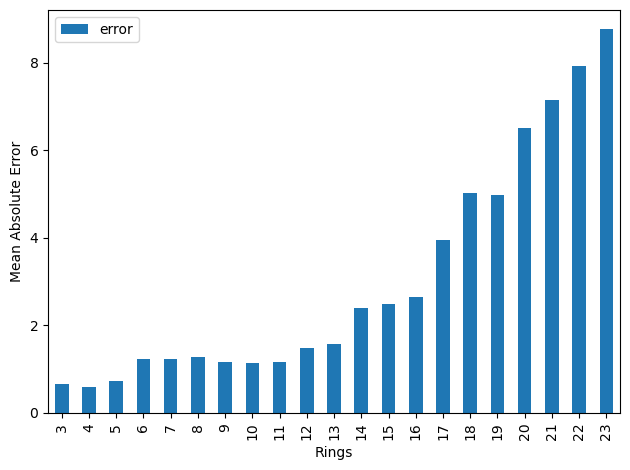

In [ ]:
y_pred = regr.predict(X_test)

avg_error_by_ring = pd.DataFrame({
    'true_ring': y_test,
    'error': abs(y_pred - y_test)
}).groupby('true_ring').mean()

avg_error_by_ring.plot(kind='bar')
plt.xlabel('Rings')
plt.ylabel('Mean Absolute Error')
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import BaggingRegressor

bag_reg = GridSearchCV(
    BaggingRegressor(
        estimator=RandomForestRegressor(
            n_estimators=100, 
            random_state=42
        ),
        n_estimators=100,
        random_state=42,
    ),
    param_grid={
        'max_samples': [0.5, 0.75, 1.0],
        'max_features': [0.5, 0.75, 1.0],
        'bootstrap': [True, False],
    },
    cv=3,
    scoring='r2',
    n_jobs=-1,
).fit(X_train, y_train)

In [ ]:
bag_reg_opt = GridSearchCV(
    BaggingRegressor(
        estimator=RandomForestRegressor(
            max_depth=9, 
            max_leaf_nodes=30, 
            min_samples_split=100, 
            n_estimators=100, 
            random_state=42
        ),
        n_estimators=100,
        random_state=42,
    ),
    param_grid={
        'max_samples': [0.5, 0.75, 1.0],
        'max_features': [0.5, 0.75, 1.0],
        'bootstrap': [True, False],
    },
    cv=3,
    scoring='r2',
    n_jobs=-1,
).fit(X_train, y_train)

In [ ]:
abalone_performance_tbl([
    ('Bagging (default)', bag_reg),
    ('Bagging (optimal)', bag_reg_opt),
])

,train,test
model,,
Bagging (default),0.749372,0.574842
Bagging (optimal),0.595557,0.555378


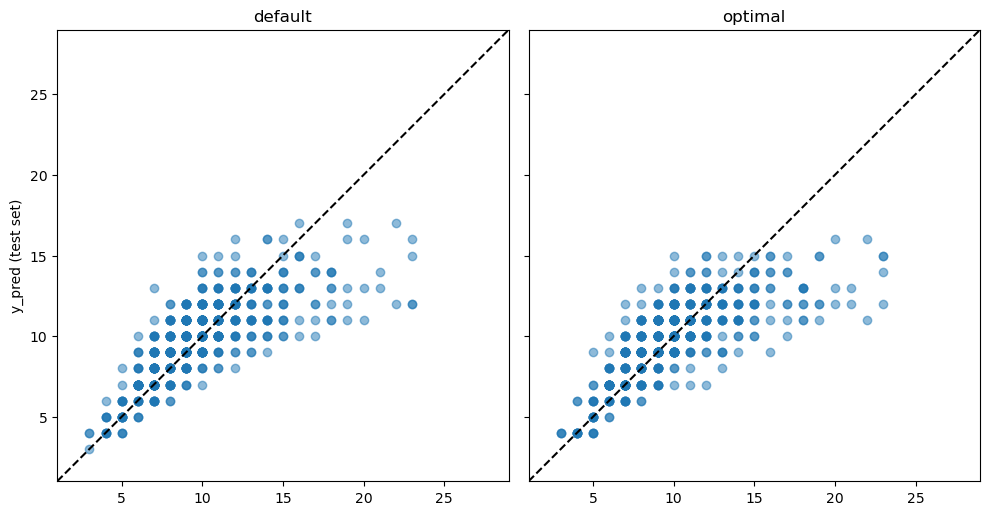

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6), sharex=True, sharey=True)

axs[0].scatter(y_test, bag_reg.predict(X_test).round(), alpha=0.5)
axs[1].scatter(y_test, bag_reg_opt.predict(X_test).round(), alpha=0.5)

for ax in axs:
    ax.plot([df['rings'].min(), df['rings'].max()], [df['rings'].min(), df['rings'].max()], 'k--')
    ax.set_xlim(df['rings'].min(), df['rings'].max())
    ax.set_ylim(df['rings'].min(), df['rings'].max())
    ax.set_aspect('equal')

axs[0].set_ylabel('y_pred (test set)')
axs[0].set_title('default')
axs[1].set_title('optimal')

plt.tight_layout()
plt.show()